In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
lattice_vectors = loadlattice("wannier.out")

3-element Vector{Vector{Float64}}:
 [-6.2541842099, 2.1665141392400002, 0.0]
 [1.25083684198, -6.499563584800001, 0.0]
 [0.0, 0.0, 21.16708]

In [3]:
write_map_write_h("wannier", [12, 12, 1], spin=Val('u'))
write_map_write_h("wannier", [12, 12, 1], spin=Val('d'))

In [4]:
force_matrix, phonon_cell_map = phonon_force_matrix("totalE");
HePhWannier, cellMapEph = write_eph_matrix_elements("wannier", 29*3, [1, 1, 1], Val('u'));

Number of phonon modes is: 87
If this is incorrect, something went wrong somewhere at some point.


In [5]:
Hwannierup, cellmapup = hwannier("wannierUp.txt", "wannierUp.map.txt"), np.loadtxt("wannierUp.map.txt");
Hwannierdn, cellmapdn = hwannier("wannierDn.txt", "wannierDn.map.txt"), np.loadtxt("wannierDn.map.txt");

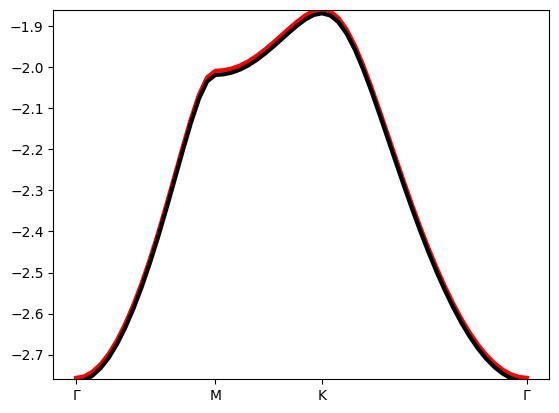

(PyCall.PyObject[PyObject <matplotlib.axis.XTick object at 0x7fd6ec1d6dc0>, PyObject <matplotlib.axis.XTick object at 0x7fd6ec1d6d90>, PyObject <matplotlib.axis.XTick object at 0x7fd6ec3458e0>, PyObject <matplotlib.axis.XTick object at 0x7fd6ec207e20>], PyCall.PyObject[PyObject Text(0, 0, 'Γ'), PyObject Text(17, 0, 'M'), PyObject Text(30, 0, 'K'), PyObject Text(55, 0, 'Γ')])

In [6]:
plotwannierbands(Hwannierup, cellmapup, 1, linewidth=3, color="red")
plotwannierbands(Hwannierdn, cellmapdn, 1, linewidth=3, color="black")

ylim(-2.76, -1.86)
label_plots()

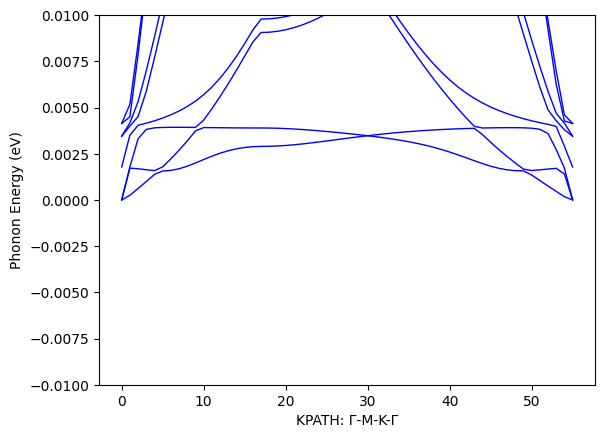

PyObject Text(0.5, 24.0, 'KPATH: Γ-M-K-Γ')

In [8]:
phonon_bands = phonon_dispersionpath(force_matrix, phonon_cell_map, kpointsfile="./bandstruct.kpoints", return_negative=true);
plot(phonon_bands[:, 1:87-28], linewidth=1, color="blue")
plot(phonon_bands[:, 87-28+1:end], linewidth=1, color="red")

ylabel("Phonon Energy (eV)")
ylim(-0.01, 0.01)
xlabel("KPATH: Γ-M-K-Γ")

In [9]:
kpts = bandstructkpoints2q(filename = "../bandstruct.kpoints")

56-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0]
 [0.029411764706, 0.0, 0.0]
 [0.058823529412, 0.0, 0.0]
 [0.088235294118, 0.0, 0.0]
 [0.117647058824, 0.0, 0.0]
 [0.147058823529, 0.0, 0.0]
 [0.176470588235, 0.0, 0.0]
 [0.205882352941, 0.0, 0.0]
 [0.235294117647, 0.0, 0.0]
 [0.264705882353, 0.0, 0.0]
 [0.294117647059, 0.0, 0.0]
 [0.323529411765, 0.0, 0.0]
 [0.352941176471, 0.0, 0.0]
 ⋮
 [0.29333333304, -0.1466666652, 0.0]
 [0.2666666664, -0.133333332, 0.0]
 [0.23999999976, -0.1199999988, 0.0]
 [0.21333333312, -0.1066666656, 0.0]
 [0.18666666648, -0.0933333324, 0.0]
 [0.15999999984, -0.0799999992, 0.0]
 [0.1333333332, -0.066666666, 0.0]
 [0.10666666656, -0.0533333328, 0.0]
 [0.07999999992, -0.0399999996, 0.0]
 [0.05333333328, -0.0266666664, 0.0]
 [0.02666666664, -0.0133333332, 0.0]
 [0.0, 0.0, 0.0]

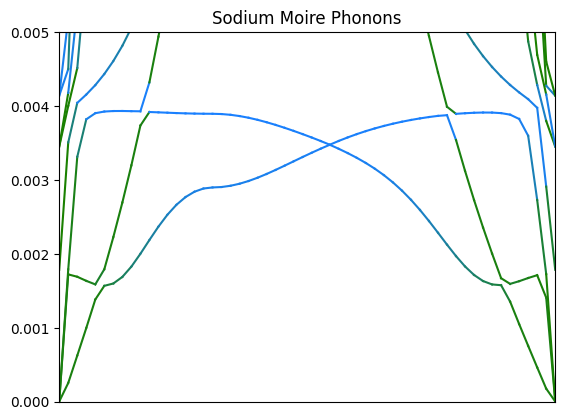

PyObject Text(0.5, 1.0, 'Sodium Moire Phonons')

In [21]:
for i in 1:87-28
    for j in 1:55
        y1= phonon_bands[j, i]
        y2 = phonon_bands[j+1, i]
        kpt = kpts[j]
        Na_Overlap = sum((abs.(phonon_dispersionmodes(force_matrix, cell_map, kpt)[2][85:87, i])).^2)
        plot([j, j+1], [y1, y2], color=[0.1, 0.5, Na_Overlap]) #linewidth=(3+Na_Overlap*4),)
    end
end
plot(phonon_bands[:, 87-28+1:end], linewidth=1, color="red")
xticks(Float64[])
ylim(0, 0.005)
xlim(1, 56)
title("Sodium Moire Phonons")

In [40]:
eph_lifetimes = [JJDFTX.migdal_approximation(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, 
lattice_vectors, unnormalize_kvector(lattice_vectors, [1, 0, 0]*i/60), -2.6,  mesh=10, histogram_width=10) for i in 1:60] 

60-element Vector{Float64}:
 0.032680431595611396
 0.038823940359654543
 0.040077694331482894
 0.03408737035392326
 0.036896769296543425
 0.02561724611008775
 0.038389060055441855
 0.022173929619297945
 0.008947698226173879
 0.0045568043632789315
 0.007263726100677648
 0.007201317127085491
 0.003055079385091026
 ⋮
 0.007263726100677679
 0.004556804363279002
 0.008947698226174118
 0.022173929619298146
 0.038389060055442376
 0.02561724611008852
 0.036896769296543515
 0.034087370353923785
 0.04007769433148359
 0.03882394035965525
 0.03268043159561168
 0.02604515283444016

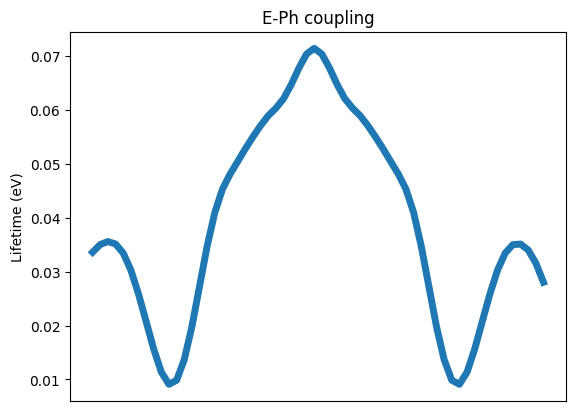

PyObject Text(24.000000000000007, 0.5, 'Lifetime (eV)')

In [42]:
plot(smooth(eph_lifetimes, win_len=10), linewidth=5)
xticks(Float64[])
title("E-Ph coupling")
ylabel("Lifetime (eV)")

In [59]:
sorderloss = second_order_damping(Hwannierup, cellmapup, HePhWannier, cellMapEph, force_matrix, phonon_cell_map, 
    lattice_vectors, q, -2.6; histogram_width=30, mesh=7, energy_range=3) 


1
1
1
1
1
1
1


90-element Vector{Float64}:
 0.0
 0.0
 0.0
 2.8547095164137954e12
 1.895620918498698e13
 1.1078739390236305e13
 2.5473004505564988e14
 4.234878398207272e14
 9.149427956187969e14
 2.8785150952562365e15
 1.4573946911460098e15
 1.5830594743704804e16
 8.477213036102494e16
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

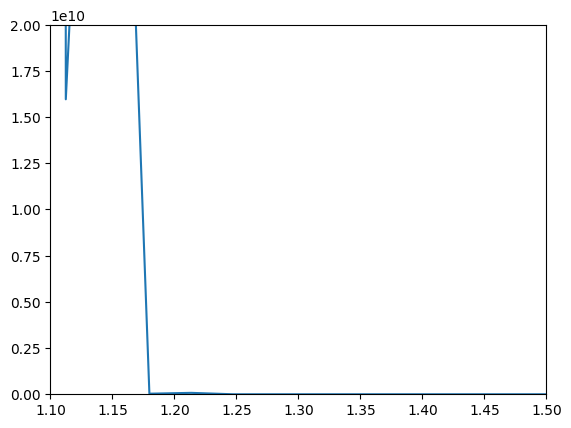

(0.0, 2.0e10)

In [58]:
plot(range(0, 3, length=90), sorderloss)
xlim(1.1, 1.5)
ylim(0, 0.2e11)

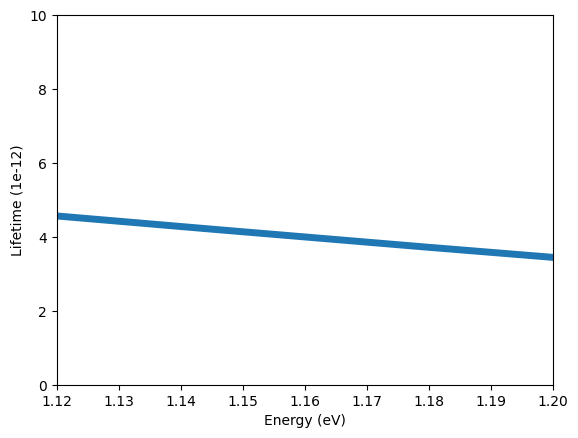

PyObject Text(0.5, 24.0, 'Energy (eV)')

In [93]:
plot(range(0, 3, length=90)[34:end], 1e12/smooth(sorderloss[34:end]), linewidth=5)
xlim(1.12, 1.2)
ylabel("Lifetime (1e-12)")
ylim(0, 10)
xlabel("Energy (eV)")

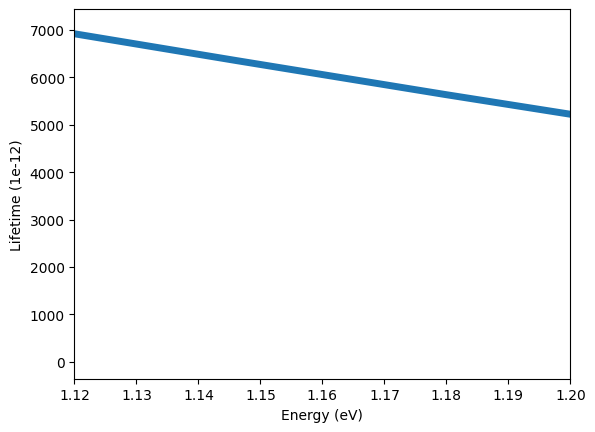

PyObject Text(0.5, 24.0, 'Energy (eV)')

In [103]:
plot(range(0, 3, length=90)[34:end], 1/smooth(sorderloss[34:end])/ħ, linewidth=5)
xlim(1.12, 1.2)
ylabel("Lifetime (1e-12)")
#ylim(0, 1000)
xlabel("Energy (eV)")

In [102]:
smooth(sorderloss[34:end])

57-element Vector{Float64}:
 5.255956216910789e10
 4.7147724309958595e10
 4.183408696068279e10
 3.66814282128136e10
 3.1748562330460213e10
 2.7088891547932102e10
 2.2749091129498474e10
 1.8767960069475677e10
 1.5175465732220604e10
 1.1992005956164314e10
 9.227906791333225e9
 6.883168237727339e9
 4.947464245320241e9
 ⋮
 0.0
 2.170138888888889e-5
 0.0
 2.170138888888889e-5
 1.0850694444444445e-5
 1.0850694444444445e-5
 1.6276041666666666e-5
 2.170138888888889e-5
 5.4253472222222224e-6
 1.6276041666666666e-5
 5.4253472222222224e-6
 1.0850694444444445e-5

In [105]:
sum(sorderloss[34:end])

7.67977313401438e10